# Proyek Analisis Data: Bike-Sharing-Dataset
- **Nama:** Fayshal Karan
- **Email:** fayshalathilla@gmail.com
- **ID Dicoding:** fayshalkaran97

## Menentukan Pertanyaan Bisnis

- Tentukan rata-rata jumlah penggunaan sepeda untuk setiap musim. Buatlah visualisasi bar chart yang menunjukkan rata-rata jumlah penggunaan sepeda per musim!
- Analisis bagaimana kondisi cuaca mempengaruhi jumlah penggunaan sepeda. Buatlah visualisasi box plot untuk menunjukkan distribusi jumlah penggunaan sepeda pada setiap kondisi cuaca!

- instant: indeks rekaman
- dteday : tanggal
- season : musim (1:musim semi, 2:musim panas, 3:musim gugur, 4:musim dingin)
- yr : tahun (0: 2011, 1:2012)
- mnth : bulan ( 1 to 12)
- hr : jam (0 to 23)
- holiday : cuaca hari libur atau tidak (diekstrak dari http://dchr.dc.gov/page/holiday-schedule)
- weekday : hari di minggu ini
- workingday : jika hari tersebut bukan hari libur atau akhir pekan nilainya 1, selain itu nilainya 0.
+ weathersit :
  - 1: Cerah, Sedikit awan, Berawan sebagian, Berawan sebagian
  - 2: Kabut + Berawan, Kabut + Awan pecah, Kabut + Sedikit awan, Kabut
  - 3: Salju Ringan, Hujan Ringan + Badai Petir + Awan Tersebar, Hujan Ringan + Awan Tersebar
  - 4: Hujan Lebat + Es + Badai Petir + Kabut, Salju + Kabut
- temp : Suhu yang dinormalkan dalam Celcius. Nilai dibagi menjadi 41 (maks)
- atemp: Suhu perasaan yang dinormalkan dalam Celcius. Nilai dibagi menjadi 50 (maks)
- hum: Kelembaban yang dinormalkan. Nilai dibagi menjadi 100 (maks)
- windspeed: Kecepatan angin yang dinormalkan. Nilai dibagi menjadi 67 (maks)
- casual: jumlah pengguna kasual
- registered: jumlah pengguna terdaftar
- cnt: jumlah total sepeda sewaan termasuk sepeda biasa dan terdaftar


## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [22]:
#membaca dataset day.csv
day_df = pd.read_csv("day.csv")

In [23]:
#membaca dataset hour.csv
hour_df = pd.read_csv("hour.csv")

### Assessing Data

In [24]:
#melihat beberapa baris data day.csv
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [7]:
#melihat informasi umum tentang data day.csv
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [52]:
#memeriksa adanya nilai yang hilang day.csv
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [53]:
#memeriksa adanya nilai duplikat day.csv
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [54]:
#melihat statistika deskriptif data
day_df.describe()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [55]:
#melihat beberapa baris data hour.csv
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [56]:
#melihat informasi umum tentang data hour.csv
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [57]:
#memeriksa adanya nilai yang hilang hour.csv
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [58]:
#memeriksa adanya nilai duplikat hour.csv
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


In [59]:
#melihat statistika deskriptif data hour.csv
hour_df.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


### Cleaning Data

In [60]:
#mengubah tipedata object pada atribut "dteday" day.csv
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

In [61]:
# Menghapus baris yang memiliki nilai yang hilang (jika ada) day.csv
day_df_clean = day_df.dropna()

In [62]:
# Menghapus duplikat (jika ada) day.csv
day_df_clean = day_df_clean.drop_duplicates()

In [63]:
# Memeriksa ulang data setelah pembersihan day.csv
day_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [64]:
#mengubah tipedata object pada atribut "dteday" hour.csv
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [65]:
# Menghapus baris yang memiliki nilai yang hilang (jika ada) hour.csv
hour_df_clean = hour_df.dropna()

In [66]:
# Menghapus duplikat (jika ada) hour.csv
hour_df_clean = hour_df_clean.drop_duplicates()

In [67]:
# Memeriksa ulang data setelah pembersihan hour.csv
print(hour_df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

## Exploratory Data Analysis (EDA)



```
# This is formatted as code
```

### Explore Data "day_df"

In [68]:
# Melihat distribusi variabel season
print(day_df_clean['season'].value_counts())

season
3    188
2    184
1    181
4    178
Name: count, dtype: int64


### Explore Data "hour_df"





In [69]:
# Melihat distribusi variabel weathersit
print(hour_df_clean['weathersit'].value_counts())

weathersit
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64


## Visualization & Explanatory Analysis

### Pertanyaan 1: Tentukan rata-rata jumlah penggunaan sepeda untuk setiap musim. Buatlah visualisasi bar chart yang menunjukkan rata-rata jumlah penggunaan sepeda per musim!

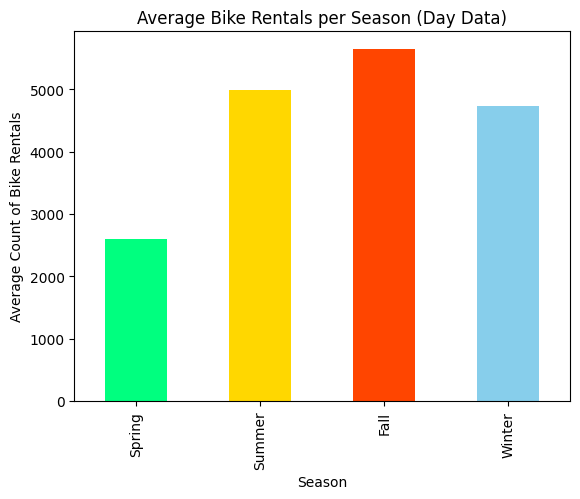

In [50]:
# Mengelompokkan data berdasarkan musim dan menghitung rata-rata jumlah penggunaan sepeda
season_avg_cnt_day = day_df_clean.groupby('season')['cnt'].mean()

# Membuat bar chart
season_avg_cnt_day.plot(kind='bar', color=['springgreen', 'gold', 'orangered', 'skyblue'])
plt.xlabel('Season')
plt.ylabel('Average Count of Bike Rentals')
plt.title('Average Bike Rentals per Season (Day Data)')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Spring', 'Summer', 'Fall', 'Winter'])
plt.show()

### Pertanyaan 2: Analisis bagaimana kondisi cuaca mempengaruhi jumlah penggunaan sepeda. Buatlah visualisasi box plot untuk menunjukkan distribusi jumlah penggunaan sepeda pada setiap kondisi cuaca!

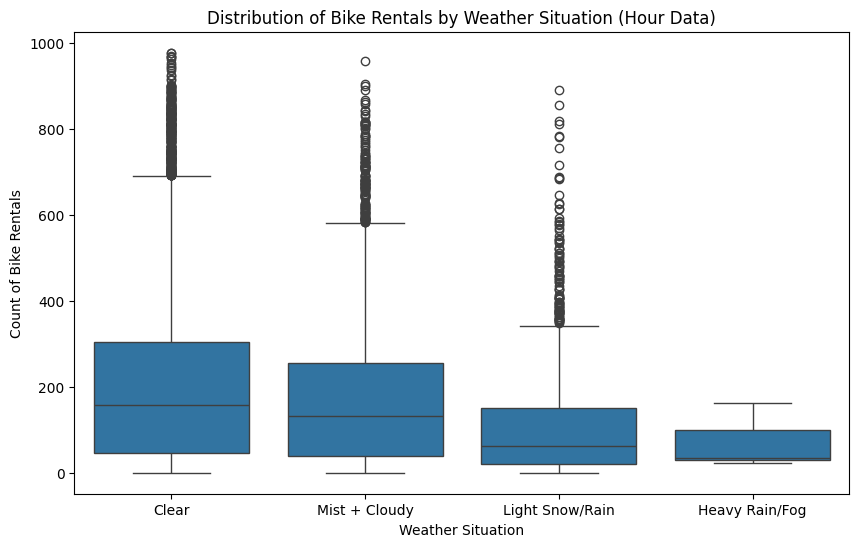

In [51]:
# Membuat box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='weathersit', y='cnt', data=hour_df_clean)
plt.xlabel('Weather Situation')
plt.ylabel('Count of Bike Rentals')
plt.title('Distribution of Bike Rentals by Weather Situation (Hour Data)')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Clear', 'Mist + Cloudy', 'Light Snow/Rain', 'Heavy Rain/Fog'])
plt.show()

## Conclusion

- **Conclution pertanyaan 1:** Diketahui bahwa rata-rata jumlah penggunaan sepeda pada musim gugur lebih banyak, dan pengguna sepada pada musim semi yang paling sedikit


- **Conclution pertanyaan 2:** Diketahui bahwa jumlah penggunaan sepeda pada keadaan cuaca hujan berat/berkabut itu lebih sedikit, dan pengguna sepeda saat keadaan cuaca cerah jauh lebih banyak

In [70]:
#unduh berkas data sebelumnya yang telah dibersihkan
day_df_clean.to_csv('day_clean.csv', index=False)
hour_df_clean.to_csv('hour_clean.csv', index=False)